# Adaptive memory testing analysis

This notebook reads the PsyNet simulated export and standalone adaptive-policy CSV evidence directly. It summarizes exported trial metadata and checks whether the adaptive policy learns sensible digit-string lengths for synthetic participants.

In [1]:
from ast import literal_eval
from pathlib import Path
from zipfile import ZipFile
import pandas as pd
import matplotlib.pyplot as plt

evidence_dir = Path('..').resolve()
standalone_csv = evidence_dir / 'standalone_simulation' / 'adaptive_policy_simulation.csv'
standalone = pd.read_csv(standalone_csv)
with ZipFile(evidence_dir / 'simulated_data.zip') as zf:
    with zf.open('regular/data/MemoryRecallTrial.csv') as f:
        exported_trials = pd.read_csv(f)
standalone.head()

,participant_key,true_r,trial_index,adaptive,selected_length,y,p_correct,posterior_r_mean,posterior_r_sd,acquisition_value,fit_ms,score_ms
0,synthetic-r-0.45,0.45,1,True,3,0,0.434598,0.577925,0.479915,0.271301,2716.807408,0.042229
1,synthetic-r-0.45,0.45,2,True,3,0,0.434598,0.548871,0.512423,0.286744,1153.862491,0.028913
2,synthetic-r-0.45,0.45,3,True,3,0,0.434598,0.576371,0.596389,0.323774,1289.883861,0.031815
3,synthetic-r-0.45,0.45,4,True,2,1,0.573753,0.292062,0.347208,0.203204,1304.611574,0.026613
4,synthetic-r-0.45,0.45,5,True,3,0,0.434598,0.524867,0.316835,0.190714,1296.499535,0.026359


In [2]:
exported_trials[['participant_id', 'trial_index', 'selected_length', 'target_string', 'raw_response', 'y', 'posterior_snapshot_id', 'acquisition_value']].head()

,participant_id,trial_index,selected_length,target_string,raw_response,y,posterior_snapshot_id,acquisition_value
0,1,1,4,3123,3123,1,participant-1-n0-s20260614,0.321967
1,1,2,6,580643,580643,1,participant-1-n1-s20260614,0.342117
2,1,3,8,69018774,69018774,1,participant-1-n2-s20260614,0.452314
3,1,4,11,04684567198,05684567198,0,participant-1-n3-s20260614,0.533473
4,1,5,8,43548711,43948711,0,participant-1-n4-s20260614,0.318562


In [3]:
def fit_ms(cell):
    if isinstance(cell, str):
        return literal_eval(cell).get('fit_posterior', 0)
    return 0

export_summary = (exported_trials
    .groupby('participant_id')
    .agg(
        n_trials=('id', 'count'),
        mean_length=('selected_length', 'mean'),
        accuracy=('y', 'mean'),
        final_posterior_r=('posterior_r_mean', 'last'),
        max_fit_ms=('timing_ms', lambda s: max(fit_ms(x) for x in s)),
    )
    .reset_index())
export_summary.head(12)

,participant_id,n_trials,mean_length,accuracy,final_posterior_r,max_fit_ms
0,1,10,7.8,0.4,1.943750,2967.788468
1,2,10,4.0,0.4,0.979633,1005.010246
2,3,10,6.9,0.3,1.292735,831.003076
3,4,10,6.6,0.5,1.851930,995.460178
4,5,10,11.0,0.5,2.447064,829.335689
5,6,10,6.0,0.4,1.431324,1114.837007
6,7,10,6.2,0.3,0.888131,815.226466
7,8,10,6.9,0.3,0.947780,817.577358
8,9,10,11.4,0.7,3.739504,1022.397167
9,10,10,12.8,0.8,3.771461,817.312136


In [4]:
summary = (
    standalone.groupby(['adaptive', 'true_r'])
    .agg(
        mean_length=('selected_length', 'mean'),
        final_posterior_r=('posterior_r_mean', 'last'),
        mean_correct=('y', 'mean'),
        mean_fit_ms=('fit_ms', 'mean'),
        max_fit_ms=('fit_ms', 'max'),
    )
    .reset_index()
)
summary

,adaptive,true_r,mean_length,final_posterior_r,mean_correct,mean_fit_ms,max_fit_ms
0,False,0.45,11.7,1.101952,0.3,726.229824,771.917355
1,False,0.75,9.6,1.029590,0.1,745.095390,805.147197
2,False,1.25,11.6,0.870352,0.1,800.173113,968.465877
3,False,2.00,12.8,0.621919,0.2,812.673842,996.090657
4,False,3.50,8.1,2.219186,0.7,797.839711,832.683915
5,True,0.45,3.0,0.439311,0.3,1459.641036,2716.807408
6,True,0.75,4.7,1.075201,0.4,730.991469,751.856117
7,True,1.25,10.1,1.963087,0.6,820.940862,1017.317492
8,True,2.00,6.7,1.629495,0.5,790.427609,830.010613
9,True,3.50,9.8,2.783976,0.8,803.931814,832.530956


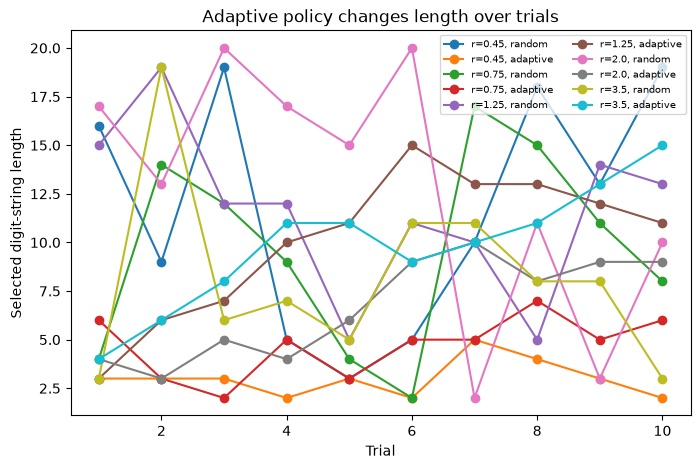

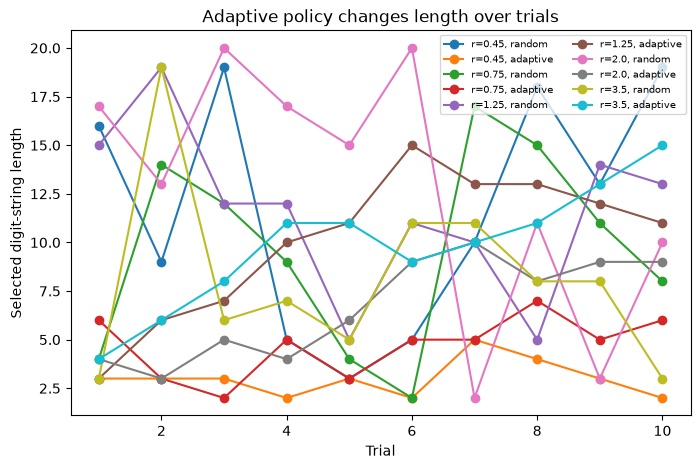

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for (true_r, adaptive), group in standalone.groupby(['true_r', 'adaptive']):
    label = f"r={true_r}, {'adaptive' if adaptive else 'random'}"
    ax.plot(group['trial_index'], group['selected_length'], marker='o', label=label)
ax.set_xlabel('Trial')
ax.set_ylabel('Selected digit-string length')
ax.set_title('Adaptive policy changes length over trials')
ax.legend(fontsize=7, ncol=2)
fig

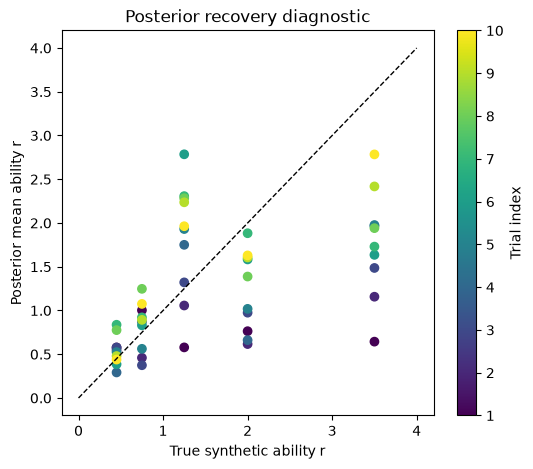

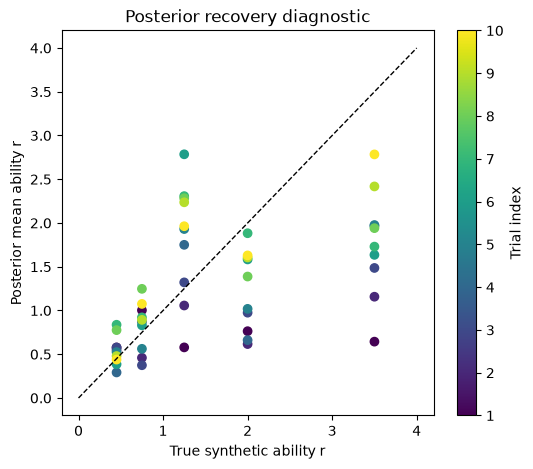

In [6]:
adaptive = standalone[standalone['adaptive']]
fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(adaptive['true_r'], adaptive['posterior_r_mean'], c=adaptive['trial_index'], cmap='viridis')
ax.plot([0, 4], [0, 4], linestyle='--', color='black', linewidth=1)
ax.set_xlabel('True synthetic ability r')
ax.set_ylabel('Posterior mean ability r')
ax.set_title('Posterior recovery diagnostic')
fig.colorbar(scatter, ax=ax, label='Trial index')
fig

## Interpretation

The PsyNet export should contain 10 finalized trials per participant with target strings, raw responses, exact-match `y`, posterior snapshot IDs, acquisition values, and timing metadata. The standalone simulation should show that selected lengths and posterior means vary with synthetic ability. Timing summaries check whether VI fitting and candidate scoring remain within the participant-response budget for this small challenge implementation.